In [2]:
# import pandas as pd
# import settings

# print("loading metadata for object and location category")
# metadata_df = pd.read_csv(settings.metadata_path)
# object_dict = {row['ImageID']: set(row['object'].split(',')) for _, row in metadata_df.iterrows() if not pd.isna(row['object'])}
# loccat_dict = {row['ImageID']: set(row['categories'].split(',')) for _, row in metadata_df.iterrows() if not pd.isna(row['categories'])}

In [3]:
# print(type(object_dict))
# # PRINT SIZE OF DICTIONARY
# print(len(object_dict))

In [1]:
# import spacy
# from textblob import TextBlob

# # parse objects and location categories from query
# def parse_objects_from_query(query):

#     # Process our query
#     print(query)
#     nlp = spacy.load("en_core_web_sm")
#     doc = nlp(query)

#     # Use blob to find words that are normal nouns
#     blob = TextBlob(doc.text)
#     all_nouns = [word for word, tag in blob.tags if tag in ['NN', 'NNS']]
    

#     # Extract noun_chunks, then extract the root from each noun_chunk
#     all_noun_chunks = [chunk.text for chunk in doc.noun_chunks if str(chunk.root) in all_nouns]
#     print(all_noun_chunks)
#     return all_noun_chunks

# text_query = "Mother Mary, pray for usâ€¦ A religious image in front of a window on a Saturday morning in Dublin City University after coffee and before a second coffee in a different cafe. It was the last day of August."
# parse_objects_from_query(text_query)

In [1]:
! pip install -U sentence-transformers

   ---------------------------------------- 0.0/156.5 kB ? eta -:--:--
   -- ------------------------------------- 10.2/156.5 kB ? eta -:--:--
   ------- ------------------------------- 30.7/156.5 kB 217.9 kB/s eta 0:00:01
   ------- ------------------------------- 30.7/156.5 kB 217.9 kB/s eta 0:00:01
   ------- ------------------------------- 30.7/156.5 kB 217.9 kB/s eta 0:00:01
   --------------- ----------------------- 61.4/156.5 kB 251.0 kB/s eta 0:00:01
   --------------- ----------------------- 61.4/156.5 kB 251.0 kB/s eta 0:00:01
   -------------------------------------- 156.5/156.5 kB 467.2 kB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 2.2.2
    Uninstalling sentence-transformers-2.2.2:
      Successfully uninstalled sentence-transformers-2.2.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
clip-retrieval 2.24.2 requires fsspec==2021.11.0, but you have fsspec 2023.10.0 which is incompatible.

[notice] A new release of pip is available: 23.3.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
print("setting up!")
from helper import setup
print("setup done!")

print(setup.OFFSET_OBJECT_START, setup.OFFSET_OBJECT_END, setup.OFFSET_LOCATION_START, setup.OFFSET_LOCATION_END)

setting up!
loading keyframe paths
Done loading keyframe paths in 107.25905919075012 seconds.

loading blip2 index
Done loading blip2 index in 356.15557289123535 seconds.

loading git index
Done loading git index in 356.58344984054565 seconds.

loading object blip2 index
Done loading object blip2 index in 356.80750036239624 seconds.

loading nlp parser
Done loading nlp parser in 359.1313440799713 seconds.

loading object list and location category list
Done loading object and location category list in 359.41955304145813 seconds.

loading metadata for object and location category


d:\VSCode\LSC24_SemanticSearchWebApp\LSC24_SemanticSearchWebApp\backend\helper\setup.py:72: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(settings.metadata_path)


Done loading metadata in 482.8960745334625 seconds.

loading fuzzy index for location search
Done loading fuzzy index in 497.63898944854736 seconds.

setup done!
0 402 402 655


In [34]:
from helper import embedding_helper, fuzzy_search
from importlib import reload
reload(embedding_helper)
reload(fuzzy_search)
# text_query = "Mother Mary, pray for us... A religious image in front of a window on a Saturday morning in Dublin City University"
# text_query = "Mother Mary, pray for us... A religious image in front of a window on a Saturday morning in Dublin City University after coffee and before a second coffee in a different cafe. It was the last day of August."
# text_query = "I was praying to small golden Buddha"
# text_query = "I was praying to small golden Buddha in a tunnel. "
# text_query = "I was praying to small golden Buddha in a tunnel. There were plants and offerings around the Buddha. "
# text_query = "I was praying to small golden Buddha in a tunnel. There were plants and offerings around the Buddha. It was inside of a tourist park with a large ornamental tower."
# text_query = "I was praying to small golden Buddha in a tunnel. There were plants and offerings around the Buddha. It was inside of a tourist park with a large ornamental tower. It was in September 2019 "
# text_query = "In disaster prepper-mode, I was buying an oversized tin of beans, incase of emergencies when covid was starting. I had looked at many large food items "
# text_query = "tins of beans, in a warehouse store called Musgrave MarketPlace"
# text_query = "Lots of colourful mugs for sale"
# text_query = "Lots of colourful mugs for sale. Yellow, red, green, blue, orange cups. "
# text_query = "colourful mugs beside some green plants in an outdoor mall"
text_query = "I think it was the second time I visited the house with the stone shed / hovel.  The shed was under green trees on a beautiful sunny day. It takes 2 hours to drive there and two hours to drive back home. It was in the middle of  Ireland on the 29th April 2020."
paths = embedding_helper.search(setup.keyframe_paths, 'image', text_query)

Received embeddings shape: torch.Size([1, 768])
colourful mugs beside some green plants in an outdoor mall
['colourful mugs', 'some green plants', 'an outdoor mall']
Received embeddings shape: torch.Size([1, 768])
Noun chunk:  colourful mugs

Received embeddings shape: torch.Size([1, 768])
Noun chunk:  some green plants

Received embeddings shape: torch.Size([1, 768])
Noun chunk:  an outdoor mall

Final objects:  ['mug', 'plant']
Final locations:  ['Shopping Plaza', 'Shopping Mall', 'Plaza', 'Retail', 'Department Store']
After loccat filter, found:  2304  results
False
After time filter, found:  2304  results
After location filter, found:  2304  results
E:\LSCDATA\keyframes\202002\20\20200220_090654_000.jpg
E:\LSCDATA\keyframes\201912\26\20191226_135525_000.jpg
E:\LSCDATA\keyframes\201902\05\20190205_161004_000.jpg
E:\LSCDATA\keyframes\202002\20\20200220_090830_000.jpg
E:\LSCDATA\keyframes\202006\15\20200615_060903_000.jpg
E:\LSCDATA\keyframes\202005\28\20200528_130800_000.jpg
E:\LSCDA

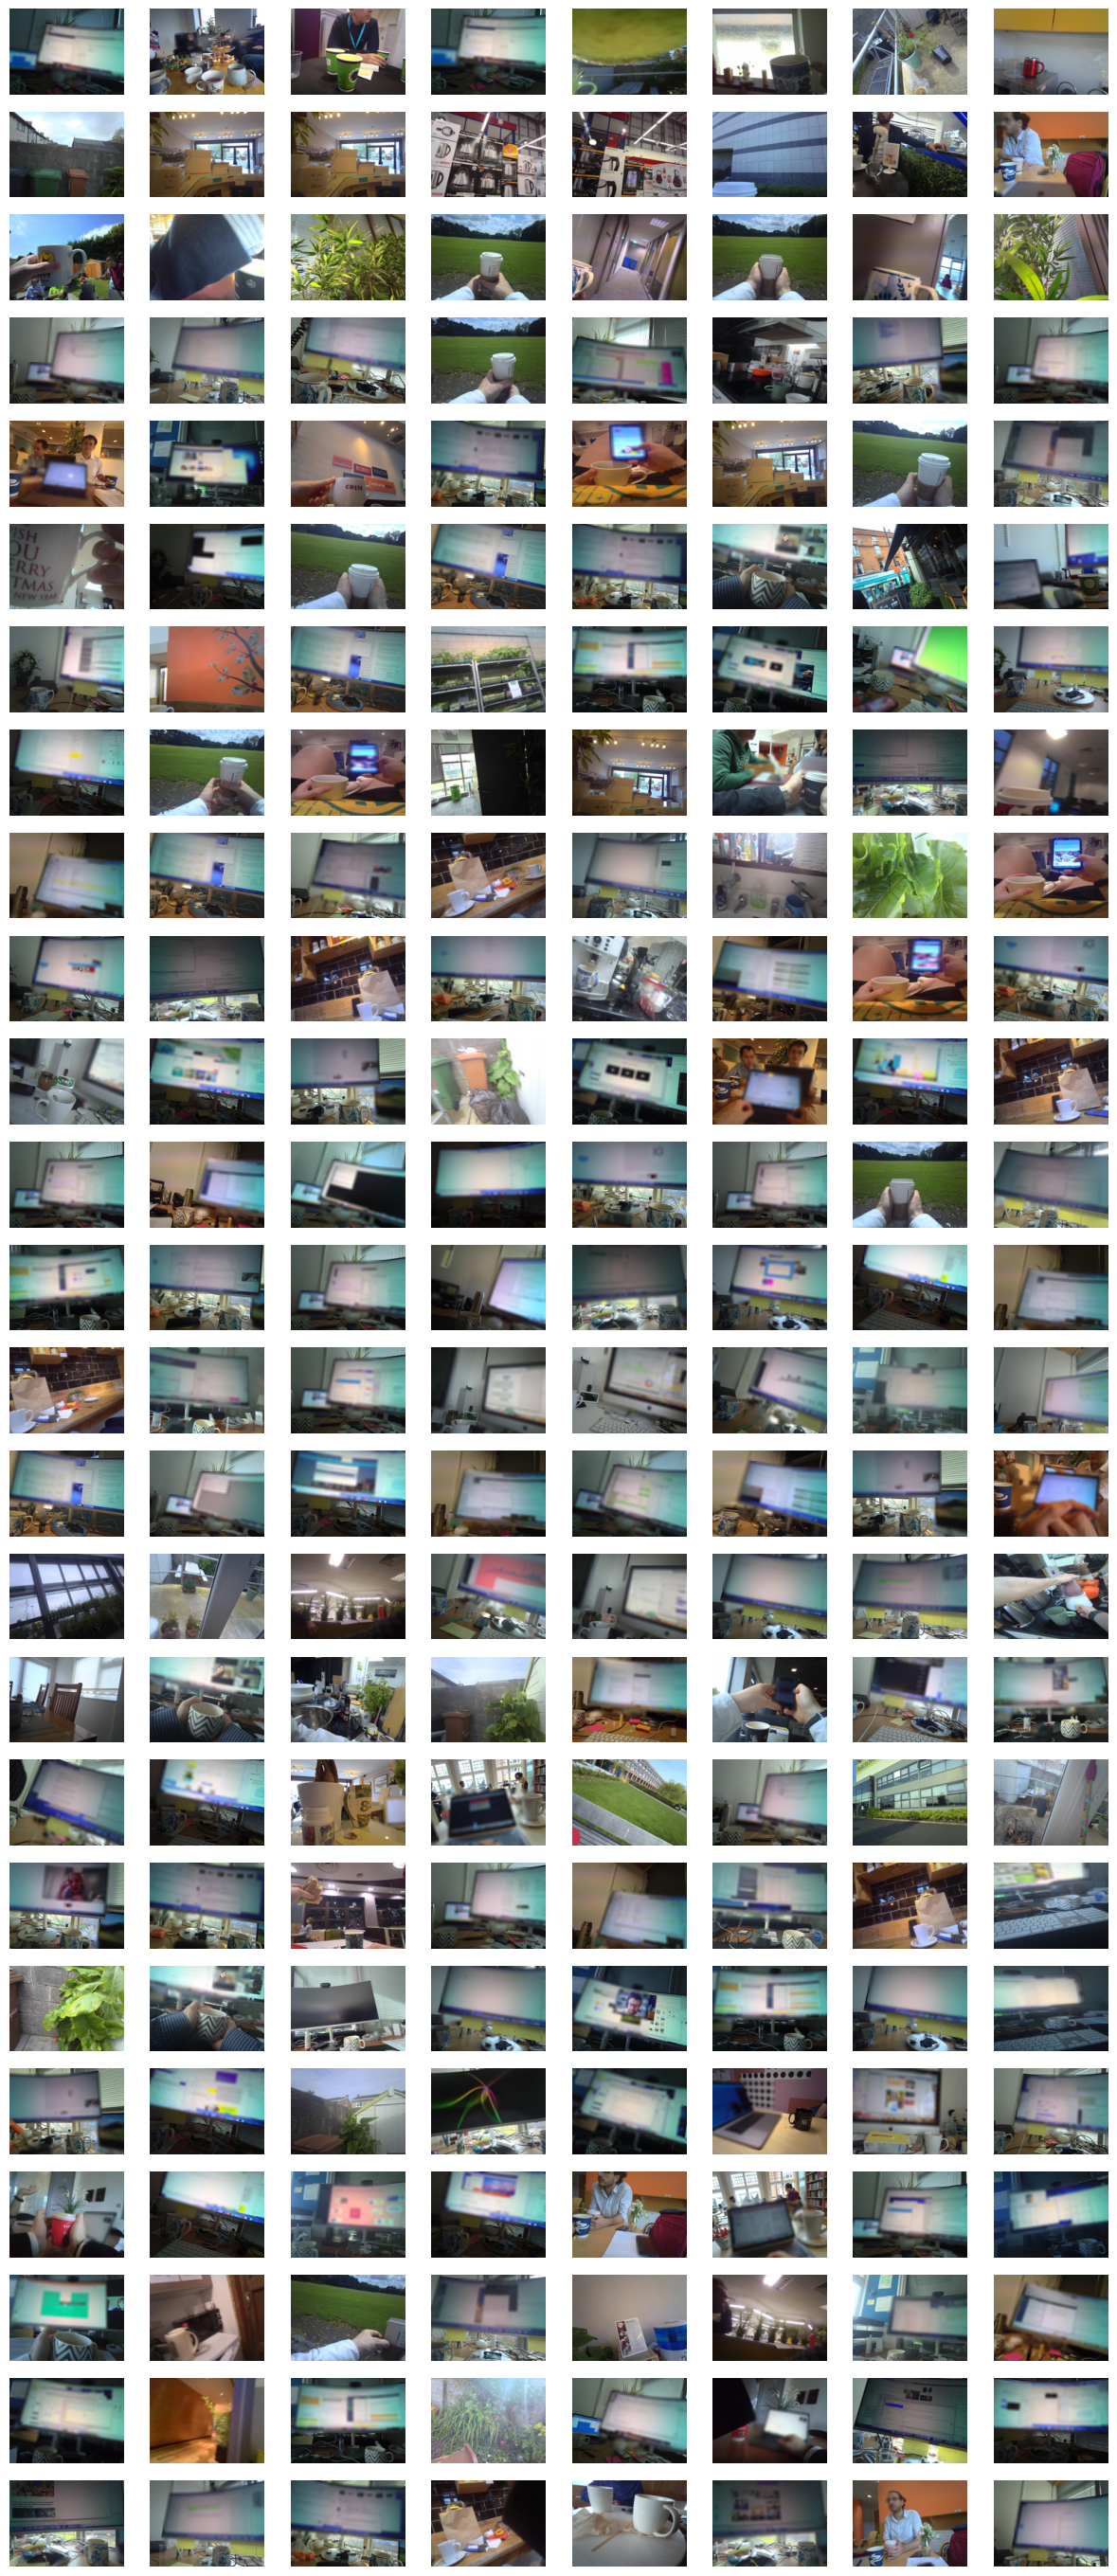

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 270))
img_count = 1

for path in paths[:200]:
    try:
        img = Image.open(path)
    except:
        continue    
    resize = (160, 120)
    img = img.resize(resize)
    plt.subplots_adjust(bottom=0.2, top=0.3)
    ax = plt.subplot(25, 8, img_count)
    ax.axis('off')
    plt.imshow(img)
    img_count += 1

In [3]:
import settings

print("loading blip2 model")
from torch import hub
hub.set_dir(settings.blip2_model_path)
import torch
from lavis.models import load_model_and_preprocess
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, vis_processors, txt_processors = load_model_and_preprocess(name="blip2_feature_extractor", model_type="pretrain", is_eval=True, device=device)
# print(f"Done loading blip2 model in {time.time() - start_time} seconds.\n")

loading blip2 model


In [4]:
txt = txt_processors["eval"](text_query)
text_sample = {"image":  [], "text_input": [txt]}
text_embedding = model.extract_features(text_sample, mode="text").text_embeds[:, 0, :]

text_embedding.shape

NameError: name 'txt_processors' is not defined